# Customer Churn Prediction — Telco Dataset

**Objective:** Identify the key drivers of customer churn for a telecom operator and build a
model that flags at-risk customers, so retention efforts can be targeted before they leave.

**Dataset:** [Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn) (7,043 customers, 21 features).

**Approach:**
1. Clean and audit the raw data
2. Explore churn patterns (contract type, pricing, service usage)
3. Engineer features that capture service adoption and cost efficiency
4. Train and compare two classification models (Logistic Regression, Random Forest)
5. Extract the top drivers of churn from the model

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["font.size"] = 11

df = pd.read_csv("data/telco_customer_churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 1. Data Cleaning

A first audit shows `TotalCharges` is stored as text (`object`) instead of a number.

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [3]:
# TotalCharges is stored as text because a handful of rows use a blank string
# instead of a numeric value. Coerce to numeric first, then look at who is affected.
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print(f"Missing TotalCharges after coercion: {df['TotalCharges'].isna().sum()}")
df.loc[df["TotalCharges"].isna(), ["tenure", "MonthlyCharges", "TotalCharges"]]

Missing TotalCharges after coercion: 11


,tenure,MonthlyCharges,TotalCharges
488,0,52.55,NaN
753,0,20.25,NaN
936,0,80.85,NaN
1082,0,25.75,NaN
1340,0,56.05,NaN
3331,0,19.85,NaN
3826,0,25.35,NaN
4380,0,20.00,NaN
5218,0,19.70,NaN
6670,0,73.35,NaN


In [4]:
# Every affected row has tenure == 0: these are brand-new customers who haven't
# been billed a full cycle yet. Their TotalCharges should equal one month's charge,
# not zero — filling with 0 would distort the price/tenure relationship for new joiners.
df["TotalCharges"] = df["TotalCharges"].fillna(df["MonthlyCharges"])
assert df["TotalCharges"].isna().sum() == 0

## 2. Exploratory Data Analysis

### 2.1 Class balance
The target variable is imbalanced, so accuracy alone won't be a reliable metric —
precision/recall per class matter more.

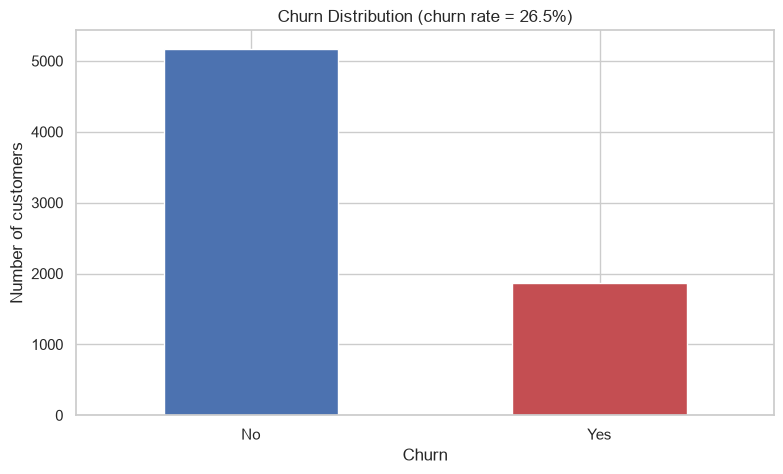

In [5]:
churn_rate = (df["Churn"] == "Yes").mean()
plt.figure()
df["Churn"].value_counts().plot(kind="bar", color=["#4C72B0", "#C44E52"])
plt.title(f"Churn Distribution (churn rate = {churn_rate:.1%})")
plt.xlabel("Churn")
plt.ylabel("Number of customers")
plt.xticks(rotation=0)
plt.show()

### 2.2 Contract type
Month-to-month contracts churn far more than one- or two-year contracts — the lack of
commitment makes leaving frictionless.

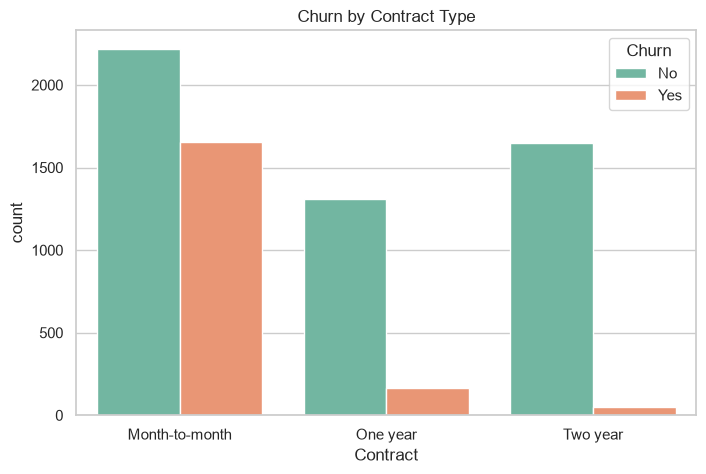

In [6]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Contract", hue="Churn", palette="Set2")
plt.title("Churn by Contract Type")
plt.show()

### 2.3 Price sensitivity
Customers who churn pay noticeably higher monthly charges on median.

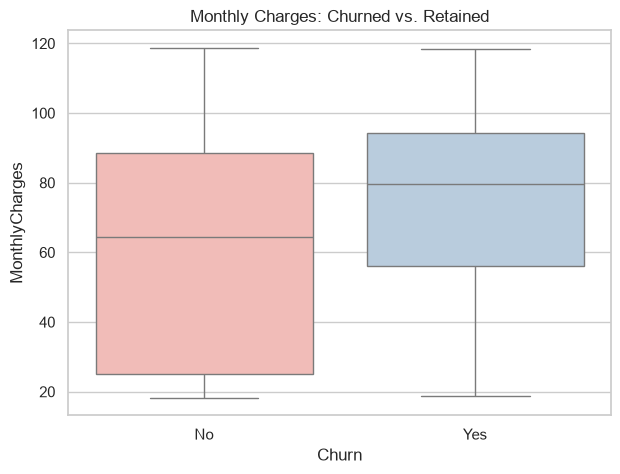

In [7]:
plt.figure(figsize=(7, 5))
sns.boxplot(x="Churn", y="MonthlyCharges", data=df, hue="Churn", palette="Pastel1", legend=False)
plt.title("Monthly Charges: Churned vs. Retained")
plt.show()

### 2.4 Fiber optic customers
Fiber optic is both the most expensive internet service and the one with the highest
churn rate — price is a likely factor, but service reliability may also play a role.

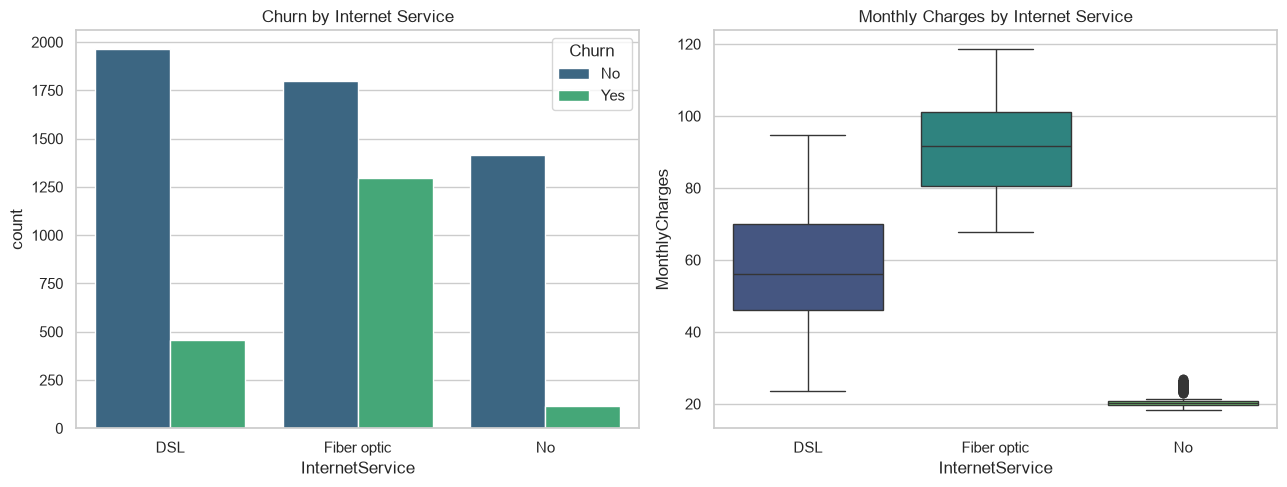

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.countplot(data=df, x="InternetService", hue="Churn", palette="viridis", ax=axes[0])
axes[0].set_title("Churn by Internet Service")
sns.boxplot(x="InternetService", y="MonthlyCharges", data=df, hue="InternetService", palette="viridis", legend=False, ax=axes[1])
axes[1].set_title("Monthly Charges by Internet Service")
plt.tight_layout()
plt.show()

### 2.5 Retention lever: Tech Support
Customers with Tech Support churn much less — it's one of the clearest retention levers
in the data.

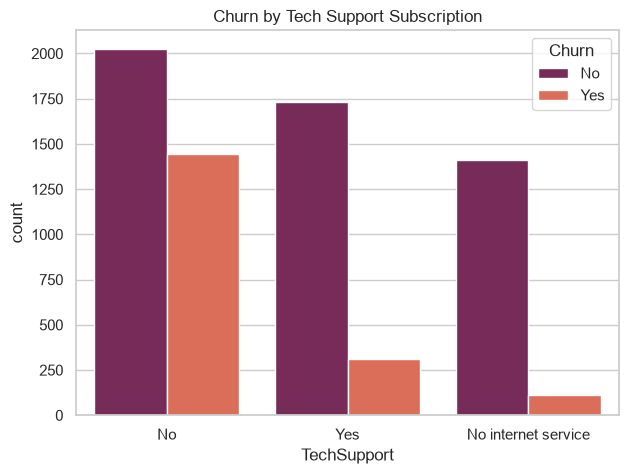

In [9]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="TechSupport", hue="Churn", palette="rocket")
plt.title("Churn by Tech Support Subscription")
plt.show()

## 3. Feature Engineering

Two engineered features to capture how "bundled in" a customer is:

- **ServiceCount**: number of add-on services subscribed (security, backup, protection,
  support, streaming) — a proxy for how embedded the customer is in the ecosystem.
- **CostPerService**: monthly charge normalized by services used — flags customers paying
  a premium relative to what they actually use.

In [10]:
service_cols = [
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies",
]
df["ServiceCount"] = (df[service_cols] == "Yes").sum(axis=1)
df["CostPerService"] = df["MonthlyCharges"] / (df["ServiceCount"] + 1)

summary = df.groupby("ServiceCount").agg(
    avg_tenure=("tenure", "mean"),
    churn_rate_pct=("Churn", lambda x: (x == "Yes").mean() * 100),
    customers=("Churn", "size"),
).round(2)
summary

,avg_tenure,churn_rate_pct,customers
ServiceCount,,,
0,24.13,21.41,2219
1,16.87,45.76,966
2,26.04,35.82,1033
3,36.67,27.37,1118
4,47.22,22.30,852
5,55.26,12.43,571
6,65.01,5.28,284


Customers with a single add-on service churn the most (45.8%) — likely internet-only
subscribers with no security or support net. Past that point the pattern is a clean,
steady decline: from 2 services onward, churn drops monotonically as more services are
added, down to 5.3% for customers with all 6 — the more embedded a customer is in the
ecosystem, the stickier they become.

## 4. Correlation Check

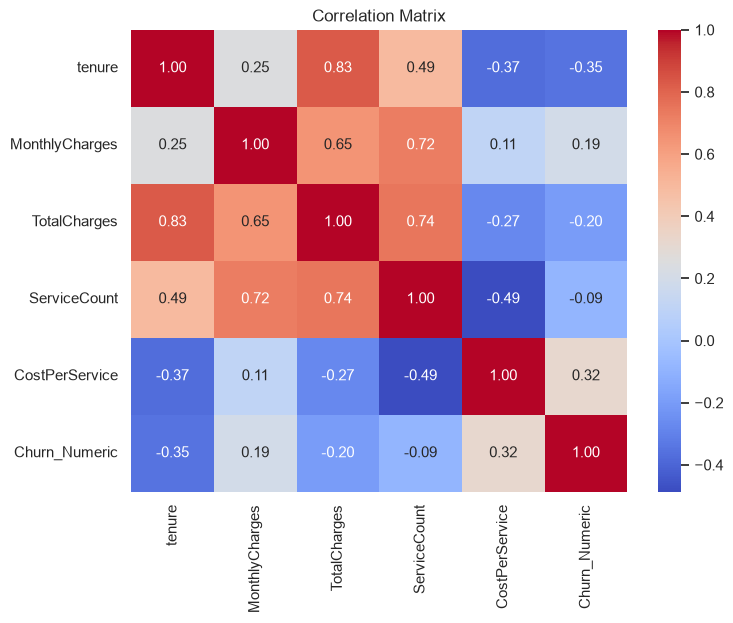

In [11]:
df["Churn_Numeric"] = df["Churn"].map({"Yes": 1, "No": 0})
corr_cols = ["tenure", "MonthlyCharges", "TotalCharges", "ServiceCount", "CostPerService", "Churn_Numeric"]

plt.figure(figsize=(8, 6))
sns.heatmap(df[corr_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

`tenure` has the strongest (negative) correlation with churn: the longer a customer
stays, the less likely they are to leave. `MonthlyCharges` and `CostPerService` are
positively correlated with churn, confirming the price-sensitivity signal from the EDA.

## 5. Modeling

Two models are compared: Logistic Regression (interpretable baseline) and Random Forest
(captures non-linear interactions, gives feature importances for driver analysis).
`customerID`, `Churn`, and `Churn_Numeric` are dropped from the features to avoid target
leakage, and the split is stratified on `Churn` to preserve the class ratio in both sets.

In [12]:
df_features = df.drop(columns=["customerID", "Churn", "Churn_Numeric"])
X = pd.get_dummies(df_features, drop_first=True)
y = df["Churn_Numeric"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Logistic Regression is sensitive to feature scale (dummies are 0/1 but tenure,
# MonthlyCharges, TotalCharges are on much larger scales), so it's wrapped in a
# scaling pipeline. Random Forest is scale-invariant and doesn't need it.
model_log = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000)),
])
model_log.fit(X_train, y_train)

model_rf = RandomForestClassifier(n_estimators=300, random_state=42)
model_rf.fit(X_train, y_train)

pred_log = model_log.predict(X_test)
pred_rf = model_rf.predict(X_test)

print(f"Logistic Regression accuracy: {accuracy_score(y_test, pred_log):.2%}")
print(f"Random Forest accuracy:       {accuracy_score(y_test, pred_rf):.2%}")

Logistic Regression accuracy: 80.70%
Random Forest accuracy:       79.21%


## 6. Evaluation

In [13]:
print("--- Logistic Regression ---")
print(classification_report(y_test, pred_log, target_names=["Retained", "Churned"]))

print("--- Random Forest ---")
print(classification_report(y_test, pred_rf, target_names=["Retained", "Churned"]))

--- Logistic Regression ---
              precision    recall  f1-score   support

    Retained       0.85      0.90      0.87      1035
     Churned       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409

--- Random Forest ---
              precision    recall  f1-score   support

    Retained       0.83      0.90      0.86      1035
     Churned       0.64      0.51      0.56       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



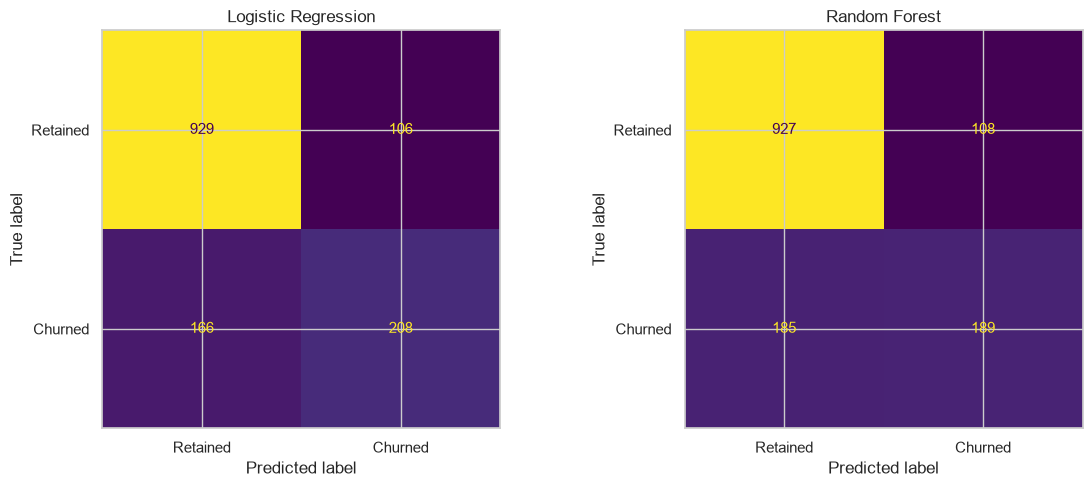

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(y_test, pred_log, display_labels=["Retained", "Churned"], ax=axes[0], colorbar=False)
axes[0].set_title("Logistic Regression")
ConfusionMatrixDisplay.from_predictions(y_test, pred_rf, display_labels=["Retained", "Churned"], ax=axes[1], colorbar=False)
axes[1].set_title("Random Forest")
plt.tight_layout()
plt.show()

## 7. Top Churn Drivers

Feature importance from the Random Forest, aggregated back to the original variables
(one-hot encoded categories summed per source column).

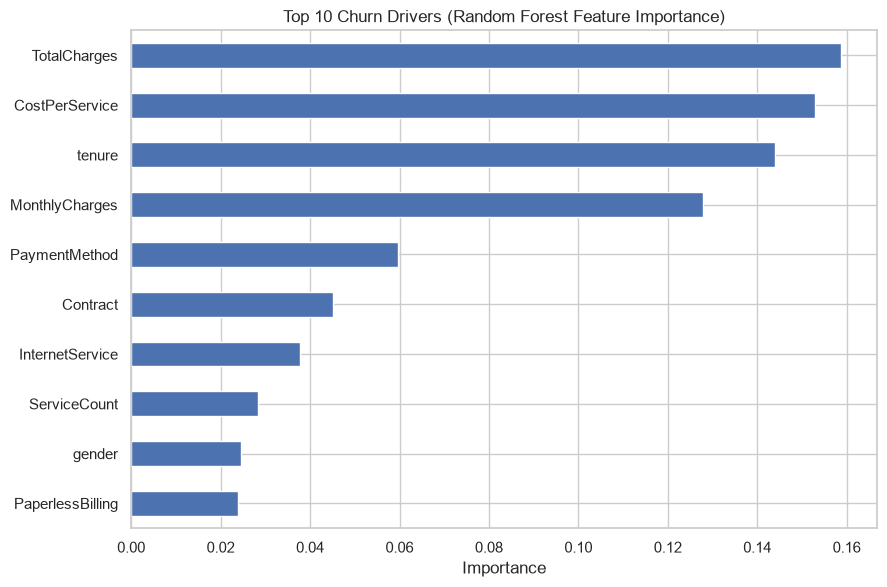

TotalCharges      0.158833
CostPerService    0.152949
tenure            0.143875
MonthlyCharges    0.127958
PaymentMethod     0.059717
dtype: float64

In [15]:
importances = pd.Series(model_rf.feature_importances_, index=X.columns)

def base_feature(col):
    for original in df_features.columns:
        if col == original or col.startswith(original + "_"):
            return original
    return col

grouped = importances.groupby(base_feature).sum().sort_values(ascending=False)

plt.figure(figsize=(9, 6))
grouped.head(10).sort_values().plot(kind="barh", color="#4C72B0")
plt.title("Top 10 Churn Drivers (Random Forest Feature Importance)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

grouped.head(5)

## Key Findings

- **Billing and tenure drive the model most**: `TotalCharges`, `CostPerService`, `tenure`
  and `MonthlyCharges` are the top 4 predictors by Random Forest importance — pricing and
  how long a customer has stayed matter more to the model than any single categorical
  attribute. *Caveat: tree-based importance is biased toward continuous/high-cardinality
  features, so this likely understates the real weight of variables like `Contract` and
  `InternetService`, which the EDA (sections 2.2–2.4) shows have a clear, strong
  relationship with churn on their own.*
- **Both models land in the same range** (~79–80% accuracy) and struggle equally with the
  minority class — recall on churned customers is 51–55%, meaning close to half of
  actual churners are still missed. That's expected on an imbalanced target with only
  ~19 features and no resampling; it's the natural next improvement (see below).
- **Service adoption retains**: churn falls steadily from 2 add-on services upward
  (down to 5.3% at 6 services), and Tech Support subscribers churn much less — bundling is
  a viable retention lever.
- **Price matters**: customers who churn pay higher `MonthlyCharges` on median, especially
  Fiber optic subscribers, who are simultaneously the most expensive and the highest-churn
  segment.

**Business recommendation:** prioritize retention outreach (discounts, contract upgrade
offers, free Tech Support trials) at customers in their first months on a month-to-month,
Fiber optic contract with few add-on services — the segment where these risk factors stack.

**Next steps to improve recall on churners:** class-balancing (SMOTE or `class_weight`),
hyperparameter tuning, and testing a gradient-boosted model (XGBoost/LightGBM).